## 0. Imports

In [ ]:
#!/usr/bin/env python3
"""
Generate timeline visualization combining ML tools and GENCODE releases.
Outputs both static (PDF/PNG) and interactive (HTML) formats.
Allows filtering of tools and GENCODE versions to display.
"""

from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
import sys
import os
from pathlib import Path

import sys
sys.path.append("/mnt/cbib/LNClassifier/paper/workflow/")
from utils import plotting

DATASET = "gencode.v47.common.cdhit.cv"
FIGURE_DIR = f"/mnt/cbib/LNClassifier/paper/results/{DATASET}/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

## 1. Utility functions

In [ ]:
def parse_date(date_str, default_day=15):
    """Parse date strings in MM.YYYY or YYYY-MM format."""
    if pd.isna(date_str):
        return None
    
    date_str = str(date_str).strip()
    
    # Handle MM.YYYY format
    if '.' in date_str:
        parts = date_str.split('.')
        if len(parts) == 2:
            month, year = int(parts[0]), int(parts[1])
            return datetime(year, month, default_day)
    
    # Handle YYYY-MM format
    if '-' in date_str:
        parts = date_str.split('-')
        if len(parts) == 2 and not "" in parts:
            year, month = int(parts[0]), int(parts[1])
            return datetime(year, month, default_day)
    
    # Handle just year
    try:
        year = int(date_str)
        return datetime(year, 6, default_day)  # Middle of year
    except:
        pass
    
    return None

def parse_gencode_versions_from_html(html_file):
    """Parse GENCODE version data from HTML file."""
    with open(html_file, 'r') as f:
        soup = BeautifulSoup(f, 'html.parser')
    
    table = soup.find('table', {'class': 'striped'}).find_all('tbody')[0]
    rows = table.find_all('tr')

    data = []
    for row in rows:
        cols = row.find_all('td')
        
        freeze_date = cols[0].text.strip()
        release = cols[1].text.strip()
        reference = cols[2].text.strip()
        release_date = cols[3].text.strip()
        assembly = cols[4].text.strip() if len(cols) > 4 else ''
        ensembl_release = cols[5].text.strip() if len(cols) > 5 else ''
        ucsc_version = cols[6].text.strip() if len(cols) > 6 else ''
        notes = cols[7].text.strip() if len(cols) > 7 else ''

        is_current = 'current' in reference.lower()
        is_reference = reference.startswith("Y")
        
        data.append({
            'freeze_date': freeze_date,
            'version': release,
            'reference': is_reference,
            'public_date': release_date,
            'assembly': assembly,
            'ensembl_release': ensembl_release,
            'ucsc_version': ucsc_version,
            'notes': notes,
            'is_current': is_current
        })
    
    return pd.DataFrame(data)


def load_tools(tools_file):
    """Load and prepare timeline data."""
    # Load tools
    tools_df = pd.read_csv(tools_file)
    tools_df['date'] = tools_df['year'].apply(lambda y: datetime(int(y), 6, 15))
    tools_df['type'] = 'Tool'
    tools_df['label'] = tools_df['tool']
    
    return tools_df


def find_tools_from_zotero(zotero_csv: str, tool_keywords: dict = None, found_only: bool=True):
    """
    Find a subset of tools from a CSV-formatted bibliography exported from Zotero
    Parameters:
        - zotero_csv: Path to the CSV file containing the exported bibliograpy
        - tool_keywords: Dictionary mapping tool names to keywords for searching titles
        - found_only: If True, only return entries where a tool was found
    """
    # Load CSV (Zotero export is quoted; keep default parsing)
    zotero_df = pd.read_csv(zotero_csv)

    zotero_df["Date"] = pd.to_datetime(zotero_df["Date"], format='mixed', errors='coerce')
    zotero_df

    default_keywords =  {
        # Tools benchmarked by us
        'CPC': 'CPC',
        'CPAT': 'CPAT',
        'CPC2': 'CPC2',
        'PLncPRO': 'PLncPRO',
        'mRNN': 'mRNN,deep recurrent neural network',
        'lncRNAnet': 'lncRNAnet',
        'LncADeep': 'LncADeep',
        'lncFinder': 'lncFinder',
        'FEELnc': 'FEELnc',
        'RNAsamba': 'RNAsamba',
        'LncDC': 'LncDC',
        'LncRNA-BERT': 'LncRNA-BERT'
    }

    if tool_keywords is None:
        tool_keywords = default_keywords
    else:
        # Append dict passed (if common keys, overwrite)
        tool_keywords = default_keywords | tool_keywords
    
    zotero_tools = zotero_df[["Title", "Date"]].rename(columns={"Title": "title", "Date": "date"}).copy()
    zotero_tools["year"] = zotero_tools["date"].dt.year
    zotero_tools['tool'] = None
    for tool, keyword in tool_keywords.items():
        for k in keyword.split(','):
            zotero_tools.loc[zotero_tools['title'].str.contains(k, case=False, na=False), 'tool'] = tool
    print(f"Found {zotero_tools['tool'].notna().sum()} / {len(tool_keywords)} tools in Zotero data")

    if found_only:
        # Remove bib entries from df if no matching tool was found
        zotero_tools.dropna(inplace=True, subset=['tool'])
        zotero_tools.reset_index(drop=True, inplace=True)

    return zotero_tools

In [ ]:
tools_file = "/mnt/cbib/LNClassifier/paper/config/timeline_tools.csv"
gencode_file = "/mnt/cbib/LNClassifier/paper/config/timeline_gencode.csv"
output_prefix = "/mnt/cbib/LNClassifier/paper/figures/timeline"

# Create output directory if needed
output_dir = Path(output_prefix).parent
output_dir.mkdir(parents=True, exist_ok=True)

# Load data
tools_df = load_tools(tools_file)
gencode_df = parse_gencode_versions_from_html("/mnt/cbib/LNClassifier/paper/config/gencode_releases.html")
print(f"Loaded {len(tools_df)} tools and {len(gencode_df)} GENCODE releases")


Loaded 30 tools and 49 GENCODE releases


In [ ]:
selected_releases = gencode_df[gencode_df['is_current'] | gencode_df['version'].isin(["5", "10", "24", "30", "40", "46", "47", "49"])].copy()
selected_releases["date"] = selected_releases["public_date"].apply(parse_date)
selected_releases["type"] = 'Database'
selected_releases["label"] = 'v' + selected_releases['version'].astype(str)

In [ ]:
selected_tools = ['CPAT', 'PLncPRO', 'mRNN', 'lncFinder',
                  'FEELnc', 'RNAsamba', 'LncDC', 'LncRNA-BERT']
filtered_tools_df = tools_df[tools_df['tool'].isin(selected_tools)]
tools_df

,tool,year,first_author,reference_doi,date,type,label
0,CPC,2007,Kong,10.1093/nar/gkm391,2007-06-15,Tool,CPC
1,PORTRAIT,2009,Arrial,10.1186/1471-2105-10-239,2009-06-15,Tool,PORTRAIT
2,CPAT,2013,Wang,10.1093/nar/gkt006,2013-06-15,Tool,CPAT
3,iSeeRNA,2013,Sun,10.1186/1471-2164-14-S2-S7,2013-06-15,Tool,iSeeRNA
4,PLEK,2014,Li,10.1186/1471-2105-15-311,2014-06-15,Tool,PLEK
5,LncRNA-ID,2015,Achawanantakun,10.1093/bioinformatics/btv480,2015-06-15,Tool,LncRNA-ID
6,lncRScan-SVM,2015,Sun,10.1371/journal.pone.0139654,2015-06-15,Tool,lncRScan-SVM
7,DeepLNC,2016,Tripathi,10.1007/s13721-016-0129-2,2016-06-15,Tool,DeepLNC
8,COME,2017,Hu,10.1093/nar/gkw798,2017-06-15,Tool,COME
9,CPC2,2017,Kang,10.1093/nar/gkx428,2017-06-15,Tool,CPC2


In [ ]:
gencode_transcripts = pd.read_csv("../gencode_stats/gencode_release_summary.csv")
gencode_transcripts["Release"] = gencode_transcripts["Release"].astype('str')
gencode_transcripts = gencode_transcripts.merge(gencode_df, left_on="Release", right_on="version")
gencode_transcripts["date"] = gencode_transcripts["public_date"].apply(parse_date)
gencode_transcripts["value"] = gencode_transcripts["lncRNA"] / 200000

In [ ]:
tool_keywords = {
    "PhyloCSF": "PhyloCSF",
    "PORTRAIT": "PORTRAIT",
    "CNCI": "Utilizing sequence intrinsic composition",
    "lncRScan": "lncRScan-SVM",
    "longdist-SVM": "A Support Vector Machine based method to distinguish",
    "COME": "COME",
    "CPPred": "CPPred",
    "PredLnc": "PredLnc",
    "LncADeep": "LncADeep"
}

zotero_path = Path('/mnt/cbib/LNClassifier/paper/config/zotero_tools.csv')
zotero_tools = find_tools_from_zotero(zotero_path, tool_keywords=tool_keywords).sort_values('date').reset_index(drop=True)

Found 20 / 20 tools in Zotero data


In [ ]:
tools_df = tools_df.set_index('tool')

tools_w_ref = [t for t in zotero_tools['tool'] if t in tools_df.index]

zotero_tools["short_ref"] = ""
zotero_tools.loc[tools_w_ref, "short_ref"] = tools_df.loc[zotero_tools["tool"], "first_author"] + " et al. " + zotero_tools["Year"].astype(str)
zotero_tools

KeyError: "['PhyloCSF', 'CNCI', 'lncRScan', 'FEELnc', 'longdist-SVM', 'lncRNAnet', 'PredLnc'] not in index"

In [ ]:
zotero_tools[["tool", "year"]].to_csv(output_dir / "timeline_zotero_tools.tsv", index=False, sep="\t")
print(f"Saved Zotero tools data to {output_dir / 'timeline_zotero_tools.tsv'}")

Saved Zotero tools data to /mnt/cbib/LNClassifier/paper/figures/timeline_zotero_tools.tsv


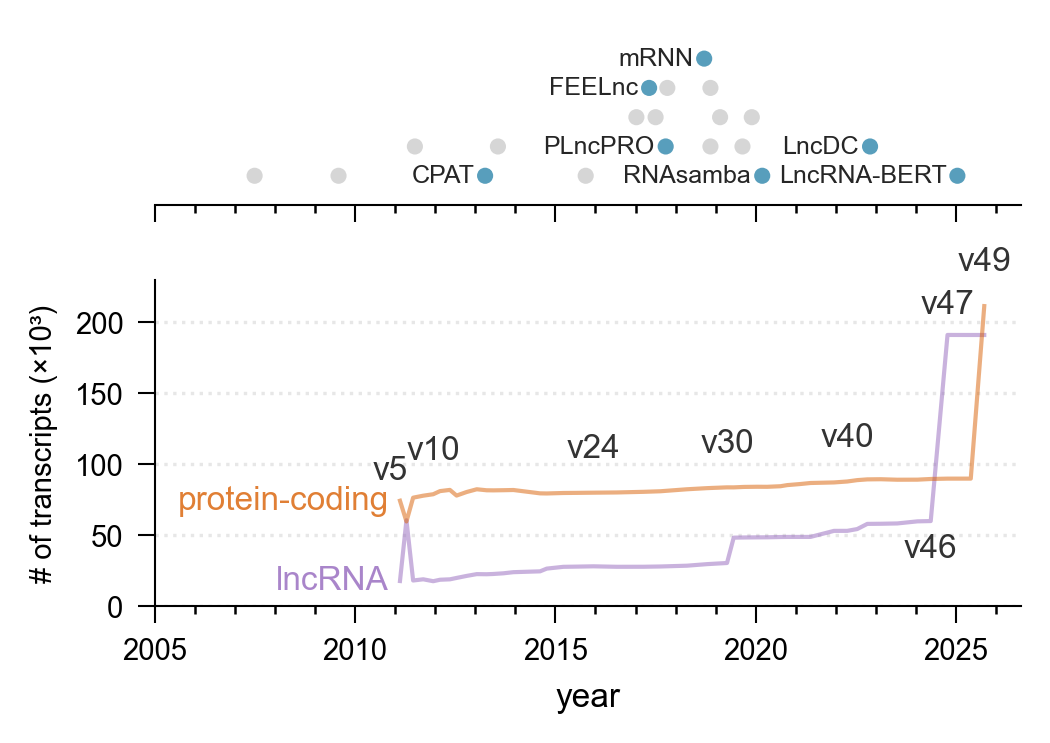

In [ ]:
############################################
# PLOT PARAMETERS
############################################
# Journal Guidelines:
# Full width, 170 mm (17 cm)
# Half width, 85 mm (8.5 cm)
# Max height, 225 mm (22.5 cm)
fig_width_cm = 8.6
fig_height_cm = 6

fig, (top_ax, bottom_ax) = plt.subplots(2, 1,
                                        figsize=(fig_width_cm/2.54, fig_height_cm/2.54),
                                        dpi=300,
                                        height_ratios=[7,13],
                                        layout='constrained')

colors = {
    'BenchTool': '#2E86AB',
    'OtherTool': '#CCCCCC',
    'Database': '#A23B72',
    'lncRNA': "#9467bd",
    'pc': '#d95f02',
}

plt.rcParams.update({"lines.linewidth": 1})

# Release configs
MIN_REL_VPOS = 0.6
OFFSET_REL_VPOS = 0.2

# Dot configs
offset_step = 0.25  # vertical distance between stacked tool points
MIN_DOT_VPOS = 1.4
OFFSET_DOT_VPOS = 0.2
X_OFFSET = pd.Timedelta(days=100)


# Manual offset of tool points
of = 0.2
offsets = [0, 0, of, 0, of, 
            0,2*of,3*of,2*of,of,
            3*of, 4*of, 3*of, of, 2*of,
            of, 2*of, 0, of, 0]


# Manual offset of release labels
release_label_offsets = {
    "v5": -0.1,
    "v46": -0.8,
    "v47": -0.1,}

################
# Prepare data
################
lncs_data =  gencode_transcripts["lncRNA"] / 100000
pc_data = gencode_transcripts["Protein-coding"] / 100000

############################################
# PLOT TOOLS (Top axis)
############################################
for idx, row in zotero_tools.iterrows():
    closest_idx = (gencode_transcripts['date'] - row['date']).abs().idxmin()
    y = offsets[idx]
    date = row['date']

    tool_color = colors['BenchTool'] if row['tool'] in selected_tools else colors['OtherTool']

    # Plot point with offset to prevent overlap
    top_ax.scatter(date, y, c=tool_color, s=60, zorder=3, alpha=0.8, marker='.', edgecolors='none')

    # Add label with slight lift relative to the point
    label = row['tool']
    rotation = 0
    va = 'bottom'
    ha = 'right'
    text_y = y - 0.08
    text_x = date - X_OFFSET
    if row['tool'] in selected_tools:
        top_ax.text(text_x, text_y, label, rotation=rotation,
                ha=ha, va=va, fontsize=6, alpha=0.85)


# Top formatting
top_ax.set_yticks([])
top_ax.set_yticklabels([])
top_ax.set_ylim(-0.2, 1)
top_ax.spines['top'].set_visible(False)
top_ax.spines['right'].set_visible(False)
top_ax.spines['left'].set_visible(False)
top_ax.tick_params(axis='x', which='both', labelbottom=False, bottom=True)
top_ax.sharex(bottom_ax)

############################################
# PLOT TIMELINE (Bottom axis)
############################################
# Plot GENCODE transcript trend lines

bottom_ax.plot(gencode_transcripts['date'], lncs_data, color=colors['lncRNA'],
        alpha=0.5, label="lncRNA transcripts", zorder=2)

bottom_ax.plot(gencode_transcripts['date'], pc_data, color=colors['pc'],
        alpha=0.5, label="Protein-coding transcripts", zorder=2)

# Plot releases
for idx, row in selected_releases.iterrows():
    # Get the maximum value at this specific release date
    closest_idx = (gencode_transcripts['date'] - row['date']).abs().idxmin()
    v_pos = max(MIN_REL_VPOS, max(pc_data.iloc[closest_idx], lncs_data.iloc[closest_idx]) + OFFSET_REL_VPOS)
    v_pos = v_pos + release_label_offsets.get(row['label'], 0)
    bottom_ax.text(row['date'], v_pos, row['label'],
            ha='center', va='bottom', fontsize=8, alpha=0.8)
    
    # line_top = max(v_pos, max(pc_data.iloc[closest_idx], lncs_data.iloc[closest_idx]))
    # line_bottom = min(v_pos, max(pc_data.iloc[closest_idx], lncs_data.iloc[closest_idx]))
    # bottom_ax.vlines(row['date'], ymin=line_bottom, ymax=line_top,
    #                  color=colors['Database'], alpha=0.7, linestyle='--',
    #                  linewidth=0.5, zorder=1)

first_date = gencode_transcripts["date"].iloc[0]
bottom_ax.text(first_date - X_OFFSET, lncs_data.iloc[0], "lncRNA", color=colors['lncRNA'],
                ha="right", va="center", fontsize=8, alpha=0.8)
bottom_ax.text(first_date - X_OFFSET, pc_data.iloc[0], "protein-coding", color=colors['pc'],
                ha="right", va="center", fontsize=8, alpha=0.8)


# Formatting
yticks = [0, 0.5, 1, 1.5, 2]
bottom_ax.set_yticks(yticks)
bottom_ax.set_yticklabels([f"{int(tick*100):,}" for tick in yticks])
bottom_ax.set_ylim(0, 2.3)
bottom_ax.set_ylabel('# of transcripts (×10³)')
bottom_ax.set_xlabel('year', fontsize=8,)


#############################################
# Common formatting
#############################################
# Share x-axis between top and bottom

# Set x-axis to show year labels every 5 years
years = pd.date_range(start=pd.Timestamp('2005-01-01'), 
                       end=pd.Timestamp('2026-01-01'), 
                       freq='YS')  # yearly ticks
bottom_ax.set_xticks(years)

# Labels only every 5 years, starting at 2005
label_years = pd.date_range(start=pd.Timestamp('2005-01-01'), 
                             end=pd.Timestamp('2026-01-01'), 
                             freq='5YS')

bottom_ax.set_xticks(label_years, minor=False)
bottom_ax.set_xticklabels([d.strftime('%Y') for d in label_years], ha='center')
bottom_ax.set_xticks(years, minor=True)


# Grid
bottom_ax.grid(axis='y', alpha=0.3, linestyle='dotted')
bottom_ax.spines['top'].set_visible(False)
bottom_ax.spines['right'].set_visible(False)
plt.rcParams['pdf.fonttype'] = 42
DATASET = "gencode.v47.common.cdhit.cv"
FIGURE_DIR = f"/mnt/cbib/LNClassifier/paper/results/{DATASET}/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURE_DIR, "timeline.pdf"), dpi=300, format='pdf')

plt.show()

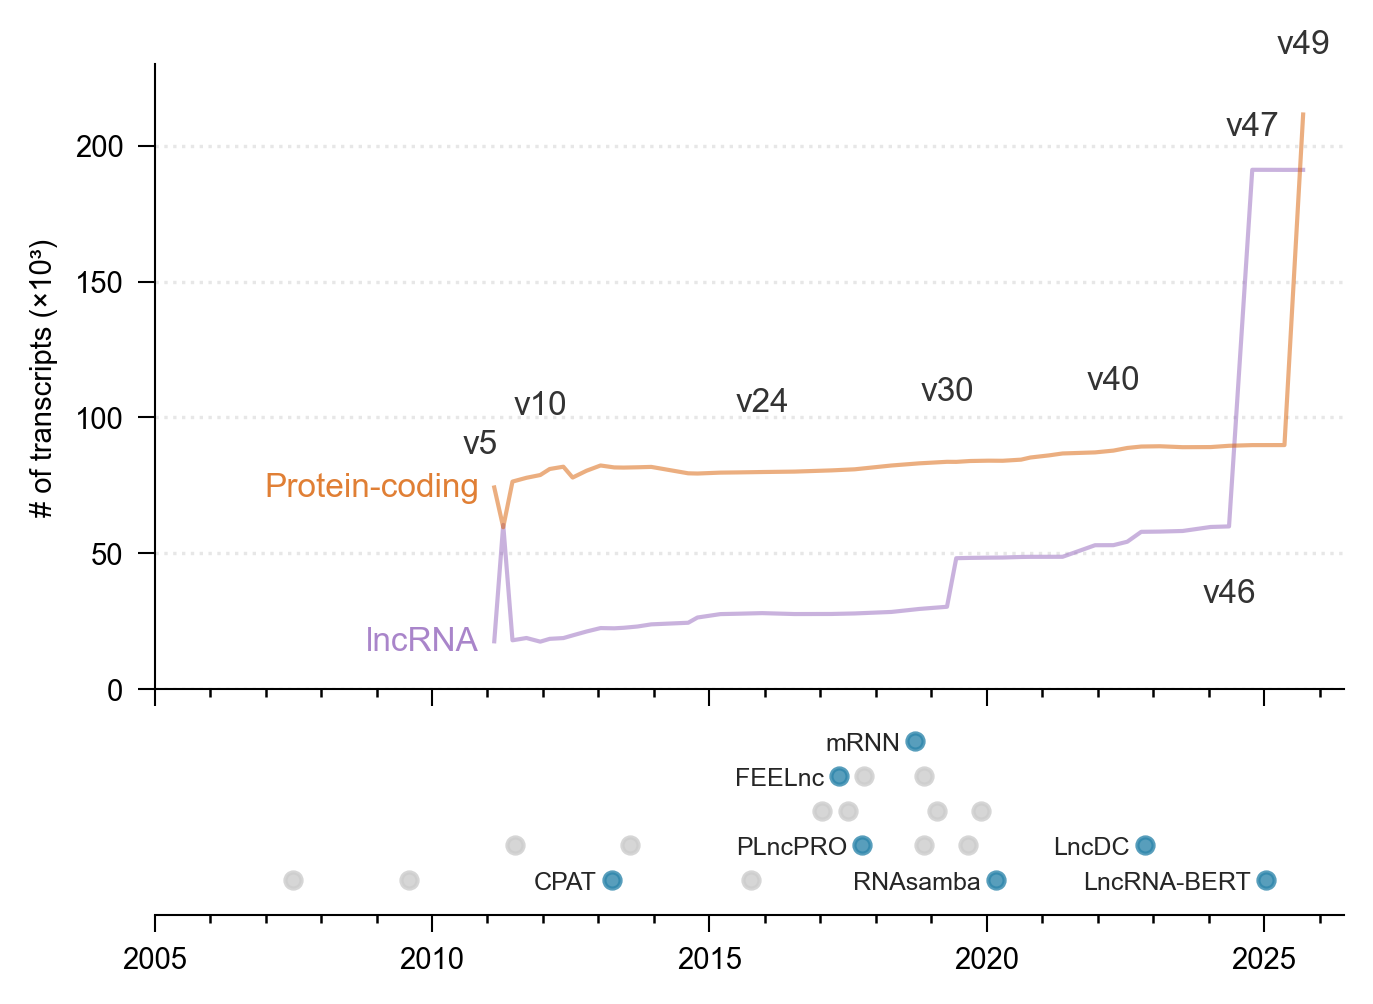

In [ ]:
############################################
# PLOT PARAMETERS
############################################
# Journal Guidelines:
# Full width, 170 mm (17 cm)
# Half width, 85 mm (8.5 cm)
# Max height, 225 mm (22.5 cm)
fig_width_cm = 17 * 2 / 3
fig_height_cm = 8

fig, (top_ax, bottom_ax) = plt.subplots(2, 1,
                                        figsize=(fig_width_cm/2.54, fig_height_cm/2.54),
                                        dpi=300,
                                        height_ratios=[15,5],
                                        layout='constrained')

############################################
# PLOT TOOLS (NOW BOTTOM)
############################################
for idx, row in zotero_tools.iterrows():
    closest_idx = (gencode_transcripts['date'] - row['date']).abs().idxmin()
    y = offsets[idx]
    date = row['date']

    tool_color = colors['BenchTool'] if row['tool'] in selected_tools else colors['OtherTool']

    # Plot point with offset to prevent overlap
    bottom_ax.scatter(date, y, c=tool_color, s=15, zorder=3, alpha=0.8)

    # Add label with slight lift relative to the point
    label = row['tool']
    rotation = 0
    va = 'bottom'
    ha = 'right'
    text_y = y - 0.08
    text_x = date - X_OFFSET
    if row['tool'] in selected_tools:
        bottom_ax.text(text_x, text_y, label, rotation=rotation,
                ha=ha, va=va, fontsize=6, alpha=0.85)


# Top formatting
bottom_ax.set_yticks([])
bottom_ax.set_yticklabels([])
bottom_ax.set_ylim(-0.2, 1)
bottom_ax.spines['top'].set_visible(False)
bottom_ax.spines['right'].set_visible(False)
bottom_ax.spines['left'].set_visible(False)
# bottom_ax.tick_params(axis='x', which='both', labelbottom=False, bottom=True)

############################################
# PLOT TIMELINE (NOW TOP)
############################################
# Plot GENCODE transcript trend lines

top_ax.plot(gencode_transcripts['date'], lncs_data, color=colors['lncRNA'],
        alpha=0.5, label="lncRNA transcripts", zorder=2)

top_ax.plot(gencode_transcripts['date'], pc_data, color=colors['pc'],
        alpha=0.5, label="Protein-coding transcripts", zorder=2)

# Plot releases
for idx, row in selected_releases.iterrows():
    # Get the maximum value at this specific release date
    closest_idx = (gencode_transcripts['date'] - row['date']).abs().idxmin()
    v_pos = max(MIN_REL_VPOS, max(pc_data.iloc[closest_idx], lncs_data.iloc[closest_idx]) + OFFSET_REL_VPOS)
    v_pos = v_pos + release_label_offsets.get(row['label'], 0)
    top_ax.text(row['date'], v_pos, row['label'],
            ha='center', va='bottom', fontsize=8, alpha=0.8)
    
    # line_top = max(v_pos, max(pc_data.iloc[closest_idx], lncs_data.iloc[closest_idx]))
    # line_bottom = min(v_pos, max(pc_data.iloc[closest_idx], lncs_data.iloc[closest_idx]))
    # top_ax.vlines(row['date'], ymin=line_bottom, ymax=line_top,
    #                  color=colors['Database'], alpha=0.7, linestyle='--',
    #                  linewidth=0.5, zorder=1)

first_date = gencode_transcripts["date"].iloc[0]
top_ax.text(first_date - X_OFFSET, lncs_data.iloc[0], "lncRNA", color=colors['lncRNA'],
                ha="right", va="center", fontsize=8, alpha=0.8)
top_ax.text(first_date - X_OFFSET, pc_data.iloc[0], "Protein-coding", color=colors['pc'],
                ha="right", va="center", fontsize=8, alpha=0.8)


# Formatting
yticks = [0, 0.5, 1, 1.5, 2]
top_ax.set_yticks(yticks)
top_ax.set_yticklabels([f"{int(tick*100):,}" for tick in yticks])
top_ax.set_ylim(0, 2.3)
top_ax.set_ylabel('# of transcripts (×10³)')
top_ax.tick_params(axis='x', which='both', labelbottom=False, bottom=True)

#############################################
# Common formatting
#############################################
# Share x-axis between top and bottom

# Set x-axis to show year labels every 5 years
years = pd.date_range(start=pd.Timestamp('2005-01-01'), 
                       end=pd.Timestamp('2026-01-01'), 
                       freq='YS')  # yearly ticks
top_ax.set_xticks(years)

# Labels only every 5 years, starting at 2005
label_years = pd.date_range(start=pd.Timestamp('2005-01-01'), 
                             end=pd.Timestamp('2026-01-01'), 
                             freq='5YS')

top_ax.set_xticks(label_years, minor=False)
top_ax.set_xticklabels([d.strftime('%Y') for d in label_years], ha='center')
top_ax.set_xticks(years, minor=True)
bottom_ax.sharex(top_ax)

# Grid
top_ax.grid(axis='y', alpha=0.3, linestyle='dotted')
top_ax.spines['top'].set_visible(False)
top_ax.spines['right'].set_visible(False)

fig.get_layout_engine().set(h_pad=-1, hspace=-1)

plt.show()